# Quantifying Momentum in Football: A Match-Level xG Analysis

The premise of this project is to model how a football game is constantly evolving and how momentum swings minute by minute using event data.

Initially we will analyse one game and go from there.

c:\Users\tamee\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


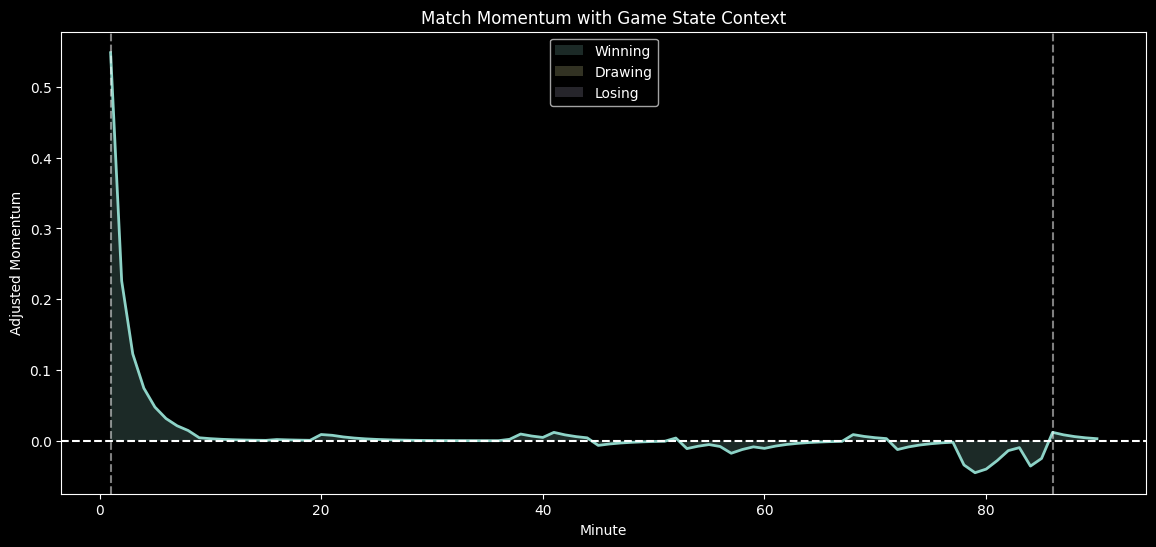

Average Momentum (Winning): 0.00946038564554639
Average Momentum (drawing): nan
Average Momentum (losing): nan


In [6]:
import requests
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
from statsbombpy import sb

match_id = 22912 #2019 champions league final 

events = sb.events(match_id=match_id)

shots = events[events["type"]== "Shot"].copy()

shots["minute"] = shots["minute"]
shots["xG"]= shots["shot_statsbomb_xg"]
shots["team"]= shots["team"]
shots["goal"] = shots["shot_outcome"] == "Goal"

shots = shots[["minute", "team", "xG", "goal"]]

teams= shots["team"].unique()
home_team = teams[0]
away_team = teams[1]

minutes= pd.DataFrame({"minute":range(1,91)})

home_xg = shots[shots["team"] == home_team].groupby("minute")["xG"].sum()
away_xg = shots[shots["team"] == away_team].groupby("minute")["xG"].sum()

timeline = minutes.merge(home_xg, on= "minute", how= "left").rename(columns={"xG": "home_xg"})
timeline = timeline.merge(away_xg, on= "minute", how= "left").rename(columns={"xG": "away_xg"})

timeline = timeline.fillna(0)

timeline["xg_diff"] = timeline["home_xg"] - timeline["away_xg"]
timeline["momentum"] = timeline["xg_diff"].ewm(alpha=0.3).mean()

home_goals = 0
away_goals = 0

game_states =[]

for minute in timeline["minute"]:
    goals_this_min = shots[(shots["minute"]== minute) & (shots["goal"])]

    for _, row in goals_this_min.iterrows():
        if row["team"] == home_team:
            home_goals += 1
        else:
            away_goals += 1
    
    if home_goals > away_goals:
        game_states.append(1)
    elif home_goals < away_goals:
        game_states.append(-1)
    else:
        game_states.append(0)

timeline["game_state"]= game_states


def adjust_momentum(row):
    if row["game_state"] == -1:    #means losing
        return row["momentum"] *1.3
    elif row["game_state"] == 1: #means winning
        return row["momentum"] *0.7
    else:
        return row["momentum"]

timeline["adjusted_momentum"] = timeline.apply(adjust_momentum, axis=1)



plt.style.use("dark_background")
plt.figure(figsize=(14,6))
plt.plot(timeline["minute"], timeline["adjusted_momentum"], linewidth =2)

#game state shading
plt.fill_between(
    timeline["minute"],
    timeline["adjusted_momentum"],
    where= timeline["game_state"] ==1,
    alpha = 0.2,
    label = "Winning"
)

plt.fill_between(
    timeline["minute"],
    timeline["adjusted_momentum"],
    where= timeline["game_state"] ==0,
    alpha = 0.2,
    label = "Drawing"
)

plt.fill_between(
    timeline["minute"],
    timeline["adjusted_momentum"],
    where= timeline["game_state"] ==-1,
    alpha = 0.2,
    label = "Losing"
)

#Goal Markers
goals = shots[shots["goal"]]

for _, row in goals.iterrows():
    plt.axvline(x=row["minute"], linestyle= "--", alpha=0.5)

plt.axhline(0, linestyle= "--")

plt.title("Match Momentum with Game State Context")
plt.xlabel("Minute")
plt.ylabel("Adjusted Momentum")

plt.legend()
plt.show()

winning = timeline[timeline["game_state"] ==1]
drawing = timeline[timeline["game_state"] ==0]
losing = timeline[timeline["game_state"] ==-1]

print("Average Momentum (Winning):", winning["adjusted_momentum"].mean())
print("Average Momentum (drawing):", drawing["adjusted_momentum"].mean())
print("Average Momentum (losing):", losing["adjusted_momentum"].mean())
